# 06 - Multivariate Analysis

## Dataset: Telco Customer Churn

Multivariate Analysis studies relationships among three or more variables.

In this notebook, we will investigate:

- Correlation Matrix
- Heatmap
- Pair Plot
- Multiple Feature Relationships
- Feature Interactions
- Numerical Feature Relationships

We will identify:

- Strong correlations
- Weak correlations
- Negative correlations
- Potential multicollinearity
- Interesting feature relationships

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Numerical Features

We will select numerical features to study their relationships.

The main numerical variables are:

- SeniorCitizen
- tenure
- MonthlyCharges
- TotalCharges

In [4]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numerical_columns].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## 2. Correlation Matrix

Correlation measures the strength and direction of a linear relationship between numerical variables.

Correlation values range from -1 to +1.

- Close to +1 → strong positive correlation
- Close to -1 → strong negative correlation
- Close to 0 → weak or no linear correlation

# Calculate correlation matrix

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

## 3. Correlation Heatmap

A heatmap provides a visual representation of the correlation matrix.

It makes it easier to identify strong positive and negative relationships between numerical variables.

In [6]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [8]:
correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


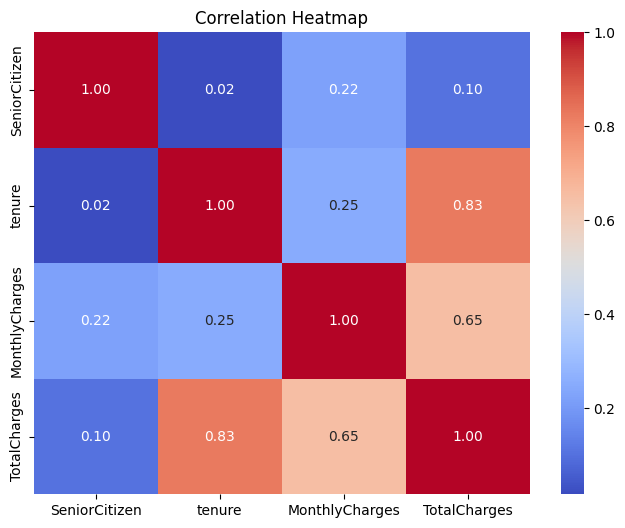

In [9]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Interpretation

Use the correlation values from the heatmap to identify:

- Strong positive correlations
- Strong negative correlations
- Weak correlations

A correlation value alone does not prove causation.

## 4. Pair Plot

A pair plot shows relationships between multiple numerical variables simultaneously.

It combines scatter plots with distributions of individual variables.

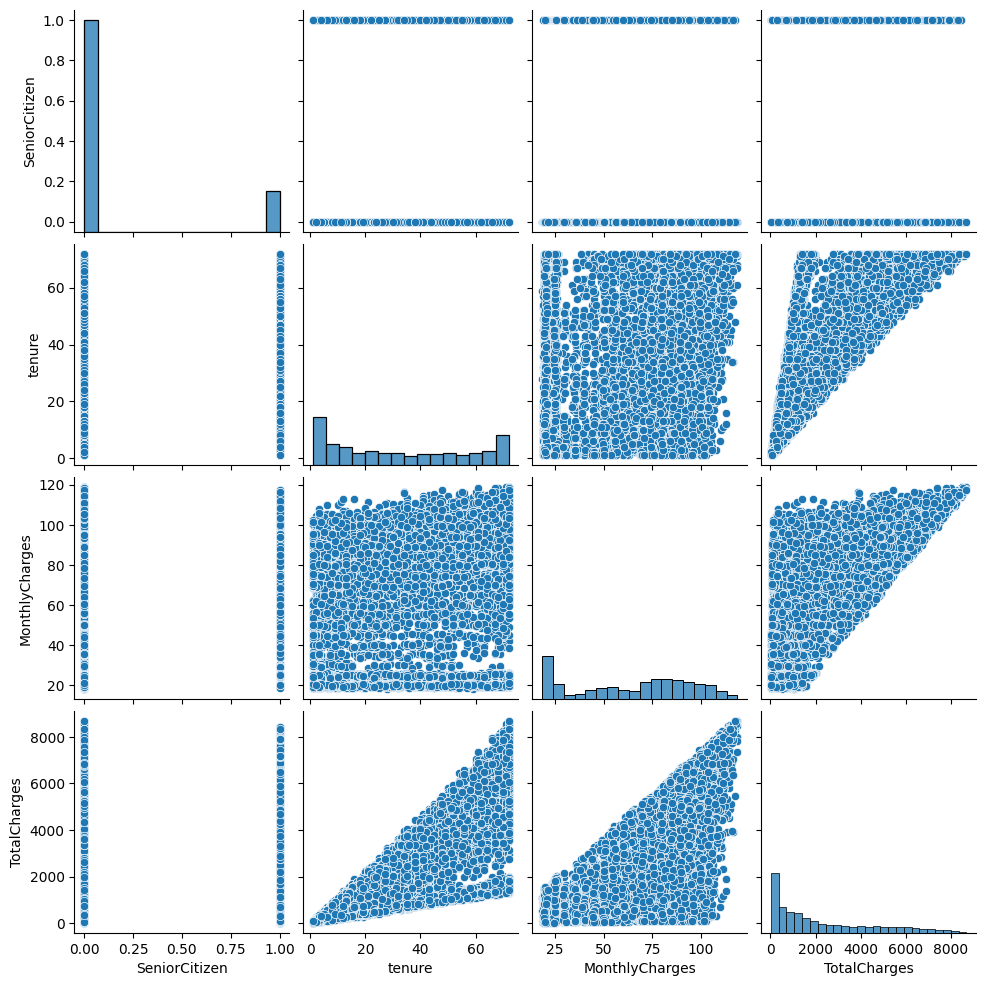

In [11]:
sns.pairplot(
    df[numerical_columns].dropna()
)

plt.show()

## 5. Multiple Feature Relationships

We can examine how multiple numerical variables relate to each other.

For example:

- Tenure vs TotalCharges
- Tenure vs MonthlyCharges
- MonthlyCharges vs TotalCharges

These relationships can help identify patterns and dependencies among features.

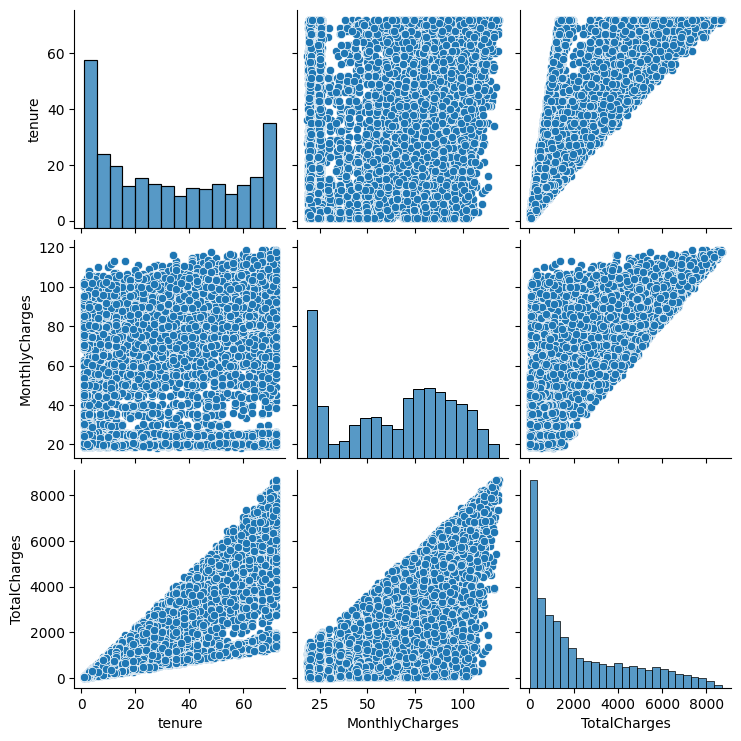

In [12]:
# Multiple feature scatter relationships

sns.pairplot(
    df[
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].dropna()
)

plt.show()

## 6. Feature Interactions

Feature interaction occurs when the relationship between one variable and another variable changes depending on a third variable.

For example, we can examine the relationship between tenure and MonthlyCharges while separating customers by Churn.

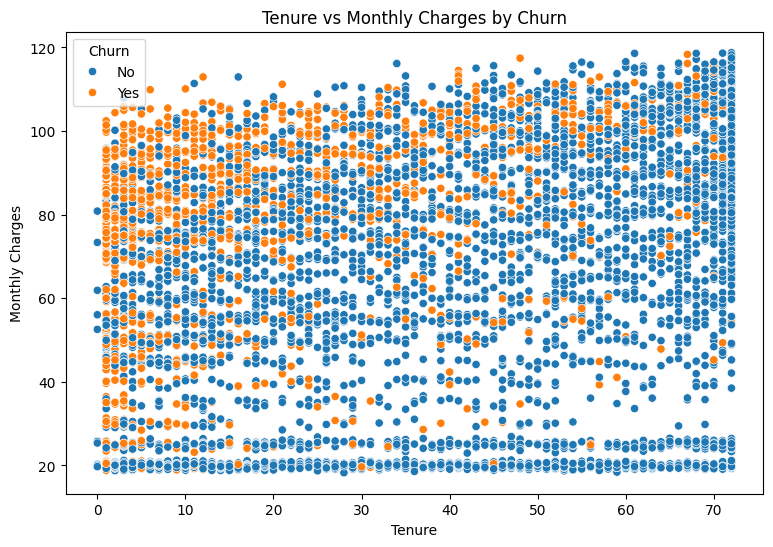

In [13]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Tenure vs Monthly Charges by Churn")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")

plt.show()

## 7. Numerical Feature Relationships

We will specifically investigate the relationship between tenure and TotalCharges.

Since TotalCharges represents the accumulated charges over time, it is useful to examine its relationship with tenure.

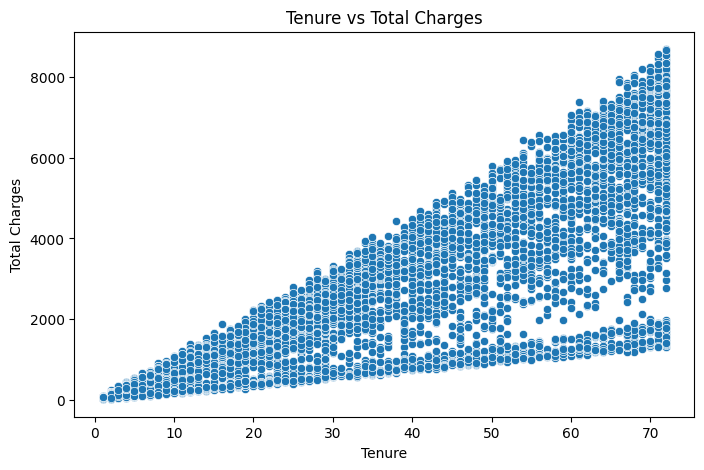

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tenure",
    y="TotalCharges"
)

plt.title("Tenure vs Total Charges")
plt.xlabel("Tenure")
plt.ylabel("Total Charges")

plt.show()

In [15]:
# Correlation between tenure and TotalCharges

df["tenure"].corr(df["TotalCharges"])

np.float64(0.8258804609332024)

## 8. Identifying Correlations

The correlation matrix can be used to identify:

### Strong Positive Correlation
A value close to +1 indicates that two variables tend to increase together.

### Strong Negative Correlation
A value close to -1 indicates that one variable tends to increase while the other decreases.

### Weak Correlation
A value close to 0 indicates a weak linear relationship.

The actual correlation values from the dataset should be used when writing the final findings.

## 9. Potential Multicollinearity

Multicollinearity occurs when two or more predictor variables are highly correlated with each other.

High correlation between features can cause problems in some statistical and machine learning models, particularly when interpreting individual coefficients.

The correlation matrix can be used as an initial check for potential multicollinearity.

In [16]:
# Display correlations between numerical features

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


### Important Note

A high pairwise correlation is an indication of potential multicollinearity, but correlation alone does not completely diagnose multicollinearity.

For a more detailed analysis, methods such as Variance Inflation Factor (VIF) can be used.

# Multivariate Analysis Summary

In this notebook, we analyzed relationships among multiple variables.

The analysis included:

- Correlation Matrix
- Correlation Heatmap
- Pair Plot
- Multiple Feature Relationships
- Feature Interactions
- Numerical Feature Relationships

We also investigated:

- Strong correlations
- Weak correlations
- Negative correlations
- Potential multicollinearity
- Interesting feature relationships

### Conclusion

Multivariate Analysis provides a broader understanding of the dataset by examining multiple variables simultaneously.

The findings can help identify important relationships and guide further feature engineering and machine learning analysis.